In [ ]:
!pip install qiskit
!pip install qiskit_aer
!pip install pylatexenc
!pip install qiskit_ibm_provider
!pip install qiskit_ibm_runtime
from qiskit import *
from qiskit_aer import *
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from qiskit.compiler import *
from qiskit.visualization import *
from qiskit.quantum_info import *
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit import QuantumCircuit
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_ibm_runtime import Sampler
import matplotlib.pyplot as plt
from qiskit.visualization import plot_histogram
from qiskit.result import marginal_counts
import numpy as np

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.5/6.5 MB 22.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 119.7/119.7 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 35.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.5/49.5 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.7/49.7 MB 17.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 109.0/109.0 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 51.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 3.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for pylatexenc: filename=pylatexenc-2.10-py3-none-any.whl size=136817 sha256=17eb0a249bc0ab7d9214f9a010dcd6951d97ff972acf47f4179418f1d233a38e
  Stored in directory: /root/.cache/pip/wheels/b1/7a/33/9fdd892f784ed4afda62b685ae3703adf4c91aa0f524c28f03
Successfully built pylatexenc
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
!git clone https://github.com/SRI-International/QC-App-Oriented-Benchmarks.git

Cloning into 'QC-App-Oriented-Benchmarks'...
remote: Enumerating objects: 11088, done.
remote: Counting objects: 100% (1012/1012), done.
remote: Compressing objects: 100% (245/245), done.
remote: Total 11088 (delta 822), reused 789 (delta 765), pack-reused 10076 (from 3)
Receiving objects: 100% (11088/11088), 130.75 MiB | 25.17 MiB/s, done.
Resolving deltas: 100% (6570/6570), done.


In [ ]:
# Hamiltonian Simulation
%cd QC-App-Oriented-Benchmarks/hamiltonian-simulation/qiskit

/content/QC-App-Oriented-Benchmarks/hamiltonian-simulation/qiskit


[Errno 2] No such file or directory: 'QC-App-Oriented-Benchmarks/hamiltonian-simulation/qiskit'
/content/QC-App-Oriented-Benchmarks/hamiltonian-simulation/qiskit
Hamiltonian Simulation Benchmark Program - Qiskit
... execution starting at Apr 25, 2025 04:08:07 UTC
************
Executing [1] circuits with num_qubits = 2


/usr/local/lib/python3.11/dist-packages/qiskit/compiler/transpiler.py:269: UserWarning: Providing `coupling_map` and/or `basis_gates` along with `backend` is not recommended, as this will invalidate the backend's gate durations and error rates.
  pm = generate_preset_pass_manager(


************
Executing [1] circuits with num_qubits = 3
************
Average Circuit Algorithmic Depth, ξ (xi) for the 2 qubit group = 47, 0.246
Average Normalized Transpiled Depth, ξ (xi), 2q gates for the 2 qubit group = 46, 0.25, 15.0
Average Creation, Elapsed, Execution Time for the 2 qubit group = 0.058, 0.213, 0.013 secs
Average Transpiling, Validating, Running Times for group 2 = 0.001, 0.001, 0.001 secs
Average Hellinger, Normalized Fidelity for the 2 qubit group = 0.948, 0.895

************
Executing [1] circuits with num_qubits = 4
************
Average Circuit Algorithmic Depth, ξ (xi) for the 3 qubit group = 72, 0.268
Average Normalized Transpiled Depth, ξ (xi), 2q gates for the 3 qubit group = 71, 0.273, 30.0
Average Creation, Elapsed, Execution Time for the 3 qubit group = 0.012, 0.248, 0.008 secs
Average Transpiling, Validating, Running Times for group 3 = 0.001, 0.001, 0.001 secs
Average Hellinger, Normalized Fidelity for the 3 qubit group = 0.549, 0.442

************
Ex

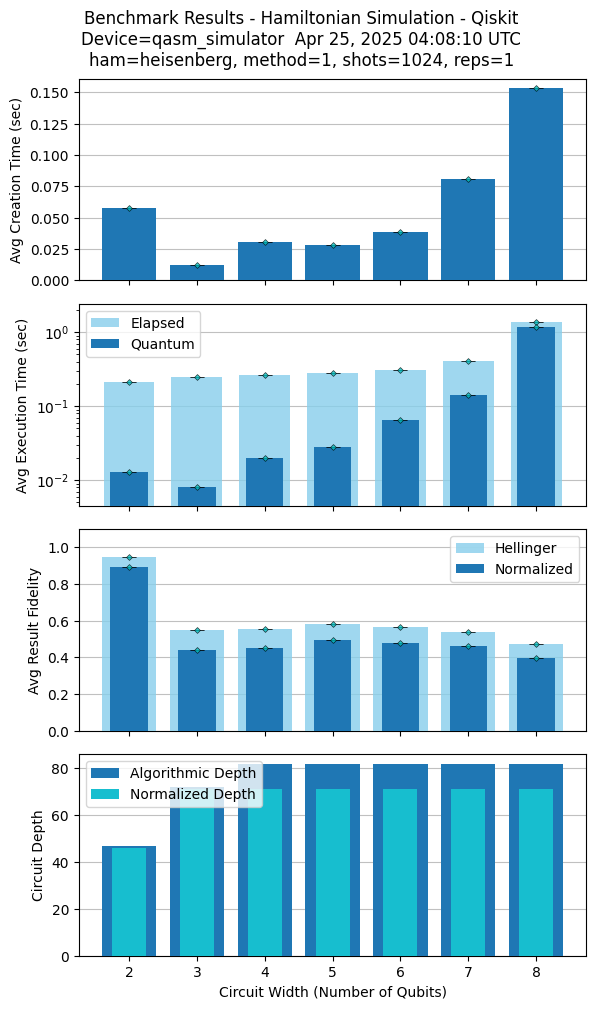

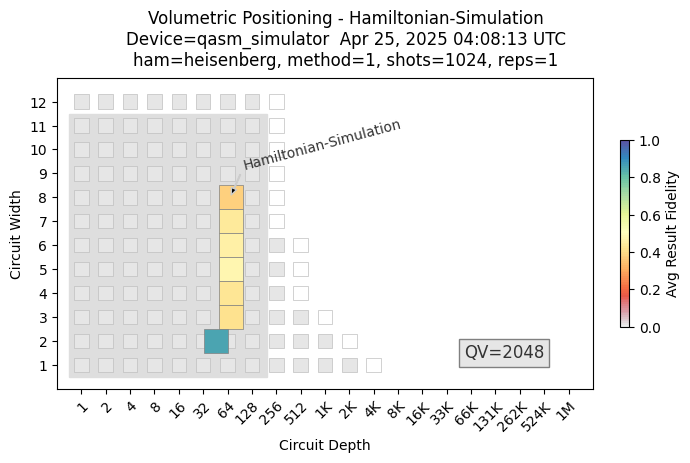

In [ ]:
# 1) Se placer dans le dossier Hamiltonian-Simulation
%cd QC-App-Oriented-Benchmarks/hamiltonian-simulation/qiskit

# 2) Choisir le backend simulateur AER
simulator = Aer.get_backend('aer_simulator')

# 3) Couper le flood stevedore (facultatif)
import logging, warnings
logging.getLogger('stevedore.extension').setLevel(logging.CRITICAL)

# 4) Importer le benchmark Hamiltonian
import hamiltonian_simulation_benchmark as hsb   # nom exact du script

# 5) Lancer le benchmark
hsb.run(
    min_qubits   = 2,        # taille mini (≥2)
    max_qubits   = 8,        # taille maxi
    skip_qubits  = 1,        # incrément
    max_circuits = 1,        # 1 circuit par taille suffit (données pré-calculées)
    num_shots    = 1024,     # tirs par circuit
    hamiltonian  = 'heisenberg',   # ou 'tfim'
    method       = 1,        # 1 = Trotter bruyant, 2 = exact classique, 3 = miroir
    use_XX_YY_ZZ_gates = False,    # True = force les portes XX/YY/ZZ non décomposées
    backend_id   = 'qasm_simulator'   # on pointe vers Aer
)

[Errno 2] No such file or directory: 'QC-App-Oriented-Benchmarks/hamiltonian-simulation/qiskit'
/content/QC-App-Oriented-Benchmarks/hamiltonian-simulation/qiskit
Hamiltonian Simulation Benchmark Program - Qiskit
... execution starting at Apr 25, 2025 04:22:12 UTC
************
Executing [1] circuits with num_qubits = 2
************
Executing [1] circuits with num_qubits = 3


/usr/local/lib/python3.11/dist-packages/qiskit/compiler/transpiler.py:269: UserWarning: Providing `coupling_map` and/or `basis_gates` along with `backend` is not recommended, as this will invalidate the backend's gate durations and error rates.
  pm = generate_preset_pass_manager(


************
Average Circuit Algorithmic Depth, ξ (xi) for the 2 qubit group = 47, 0.246
Average Normalized Transpiled Depth, ξ (xi), 2q gates for the 2 qubit group = 46, 0.25, 15.0
Average Creation, Elapsed, Execution Time for the 2 qubit group = 0.017, 0.261, 0.034 secs
Average Transpiling, Validating, Running Times for group 2 = 0.001, 0.001, 0.001 secs
Average Hellinger, Normalized Fidelity for the 2 qubit group = 0.912, 0.829

************
Executing [1] circuits with num_qubits = 4
************
Average Circuit Algorithmic Depth, ξ (xi) for the 3 qubit group = 72, 0.268
Average Normalized Transpiled Depth, ξ (xi), 2q gates for the 3 qubit group = 71, 0.273, 30.0
Average Creation, Elapsed, Execution Time for the 3 qubit group = 0.042, 0.239, 0.017 secs
Average Transpiling, Validating, Running Times for group 3 = 0.001, 0.001, 0.001 secs
Average Hellinger, Normalized Fidelity for the 3 qubit group = 0.877, 0.798

************
Executing [1] circuits with num_qubits = 5
************
Av

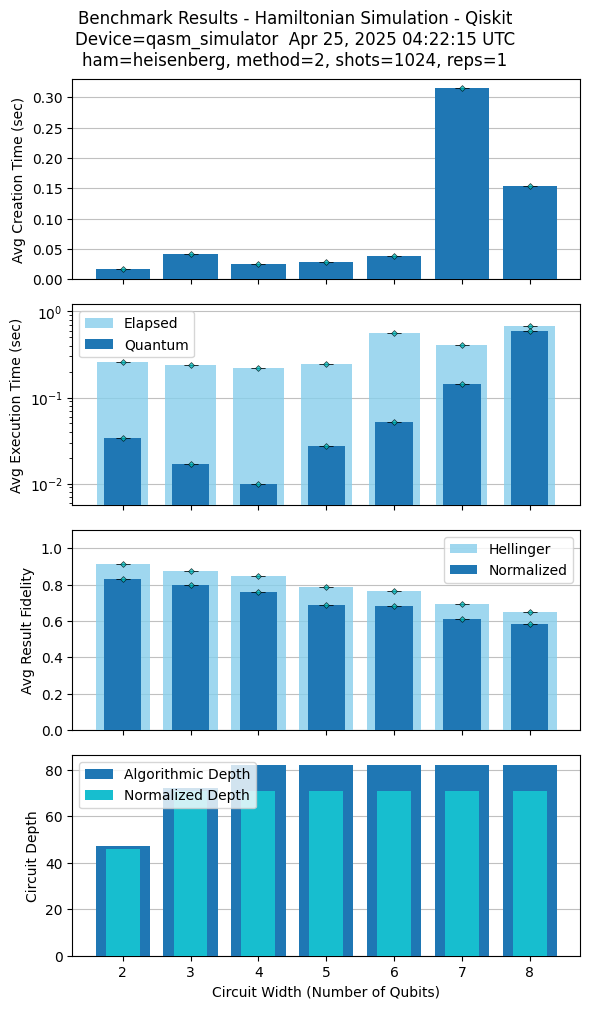

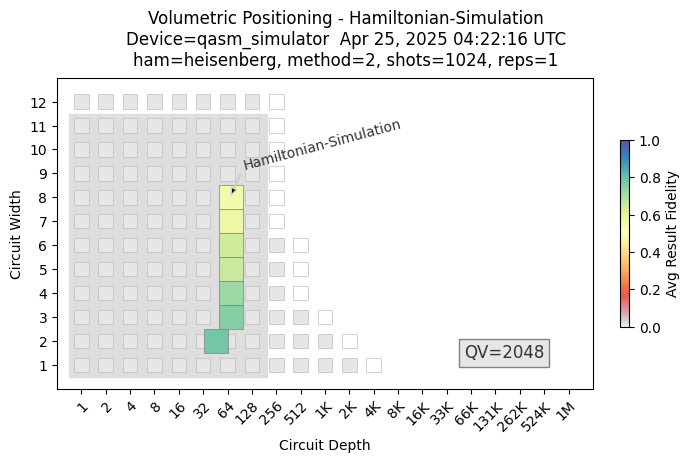

In [ ]:
# 1) Se placer dans le dossier Hamiltonian-Simulation
%cd QC-App-Oriented-Benchmarks/hamiltonian-simulation/qiskit

# 2) Choisir le backend simulateur AER
simulator = Aer.get_backend('aer_simulator')

# 3) Couper le flood stevedore (facultatif)
import logging, warnings
logging.getLogger('stevedore.extension').setLevel(logging.CRITICAL)

# 4) Importer le benchmark Hamiltonian
import hamiltonian_simulation_benchmark as hsb   # nom exact du script

# 5) Lancer le benchmark
hsb.run(
    min_qubits   = 2,        # taille mini (≥2)
    max_qubits   = 8,        # taille maxi
    skip_qubits  = 1,        # incrément
    max_circuits = 1,        # 1 circuit par taille suffit (données pré-calculées)
    num_shots    = 1024,     # tirs par circuit
    hamiltonian  = 'heisenberg',   # ou 'tfim'
    method       = 2,        # 1 = Trotter bruyant, 2 = exact classique, 3 = miroir
    use_XX_YY_ZZ_gates = False,    # True = force les portes XX/YY/ZZ non décomposées
    backend_id   = 'qasm_simulator'   # on pointe vers Aer
)

[Errno 2] No such file or directory: 'QC-App-Oriented-Benchmarks/hamiltonian-simulation/qiskit'
/content/QC-App-Oriented-Benchmarks/hamiltonian-simulation/qiskit
Hamiltonian Simulation Benchmark Program - Qiskit
... execution starting at Apr 25, 2025 04:23:05 UTC
************
Executing [1] circuits with num_qubits = 2


/usr/local/lib/python3.11/dist-packages/qiskit/compiler/transpiler.py:269: UserWarning: Providing `coupling_map` and/or `basis_gates` along with `backend` is not recommended, as this will invalidate the backend's gate durations and error rates.
  pm = generate_preset_pass_manager(


************
Executing [1] circuits with num_qubits = 3
************
Average Circuit Algorithmic Depth, ξ (xi) for the 2 qubit group = 92, 0.248
Average Normalized Transpiled Depth, ξ (xi), 2q gates for the 2 qubit group = 91, 0.25, 30.0
Average Creation, Elapsed, Execution Time for the 2 qubit group = 0.025, 0.351, 0.033 secs
Average Transpiling, Validating, Running Times for group 2 = 0.001, 0.001, 0.001 secs
Average Hellinger, Normalized Fidelity for the 2 qubit group = 0.863, 0.818

************
Executing [1] circuits with num_qubits = 4
************
Average Circuit Algorithmic Depth, ξ (xi) for the 3 qubit group = 142, 0.27
Average Normalized Transpiled Depth, ξ (xi), 2q gates for the 3 qubit group = 141, 0.273, 60.0
Average Creation, Elapsed, Execution Time for the 3 qubit group = 0.024, 0.278, 0.015 secs
Average Transpiling, Validating, Running Times for group 3 = 0.001, 0.001, 0.001 secs
Average Hellinger, Normalized Fidelity for the 3 qubit group = 0.738, 0.701

************
E

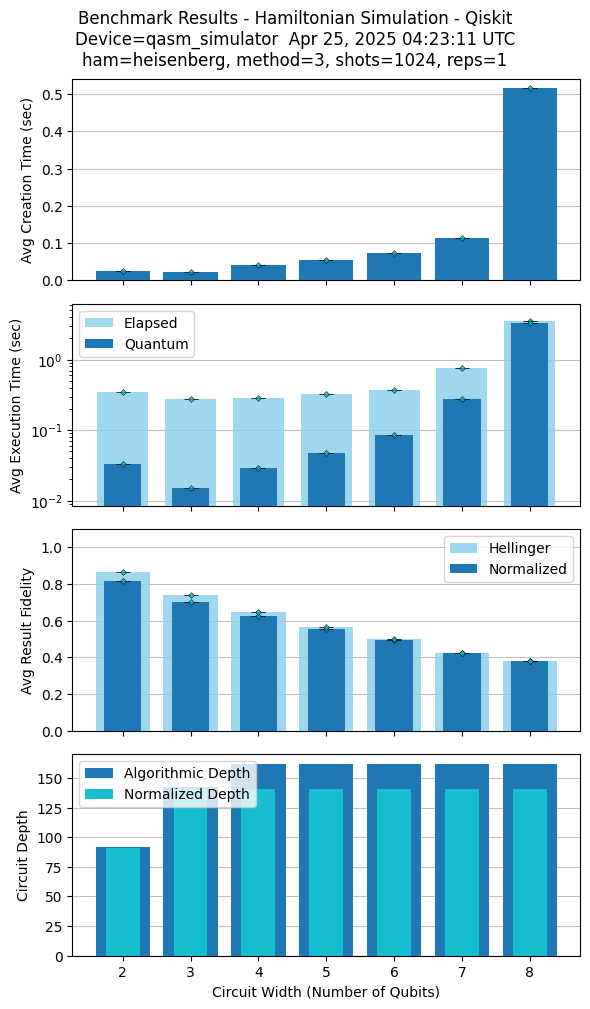

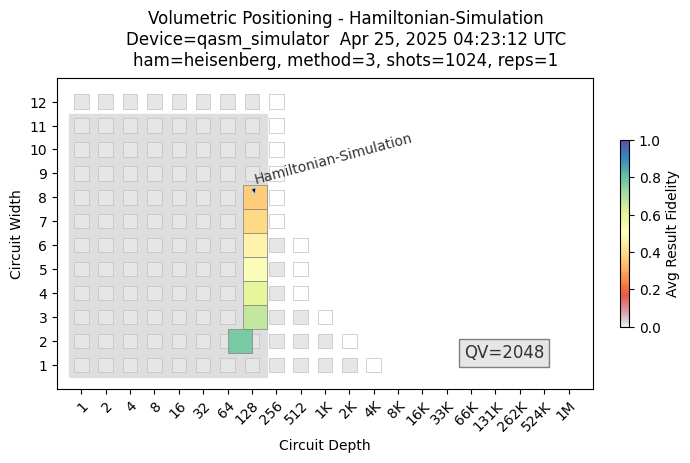

In [ ]:
# 1) Se placer dans le dossier Hamiltonian-Simulation
%cd QC-App-Oriented-Benchmarks/hamiltonian-simulation/qiskit

# 2) Choisir le backend simulateur AER
simulator = Aer.get_backend('aer_simulator')

# 3) Couper le flood stevedore (facultatif)
import logging, warnings
logging.getLogger('stevedore.extension').setLevel(logging.CRITICAL)

# 4) Importer le benchmark Hamiltonian
import hamiltonian_simulation_benchmark as hsb   # nom exact du script

# 5) Lancer le benchmark
hsb.run(
    min_qubits   = 2,        # taille mini (≥2)
    max_qubits   = 8,        # taille maxi
    skip_qubits  = 1,        # incrément
    max_circuits = 1,        # 1 circuit par taille suffit (données pré-calculées)
    num_shots    = 1024,     # tirs par circuit
    hamiltonian  = 'heisenberg',   # ou 'tfim'
    method       = 3,        # 1 = Trotter bruyant, 2 = exact classique, 3 = miroir
    use_XX_YY_ZZ_gates = False,    # True = force les portes XX/YY/ZZ non décomposées
    backend_id   = 'qasm_simulator'   # on pointe vers Aer
)

Répertoire courant AVANT changement: /content/QC-App-Oriented-Benchmarks/hamiltonian-simulation/qiskit
Déjà dans le bon répertoire: /content/QC-App-Oriented-Benchmarks/hamiltonian-simulation/qiskit
Using backend: ibm_sherbrooke
Backend basis gates: ['ecr', 'id', 'rz', 'sx', 'x']
... execution starting at Apr 25, 2025 04:28:37 UTC

Generating circuits for 2 to 8 qubits (Hamiltonian Simulation - heisenberg)...
... 2 qubits
... 3 qubits
... 4 qubits
... 5 qubits
... 6 qubits
... 7 qubits
... 8 qubits

Generated 7 circuits in 0.23s.

Transpiling 7 circuits for ibm_sherbrooke...
Attempting transpilation with optimization_level=1...
Transpilation finished in 0.15s.

Submitting 7 transpiled circuits...
Job submitted: d05gyy36rr3g008tf1zg
Waiting for results...
Job finished in 22.11s.

Analyzing 7 results...
Total quantum execution time (reported by IBM): 3.0000s

Finalizing metric groups (for internal state)...
************
Average Circuit Algorithmic Depth, ξ (xi) for the 2 qubit group = 47,

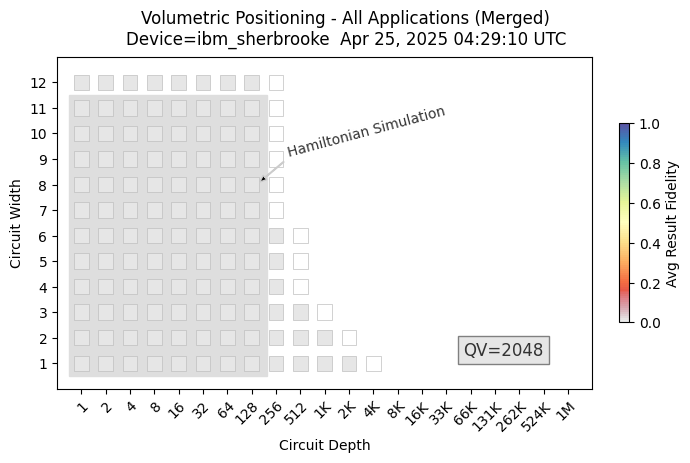

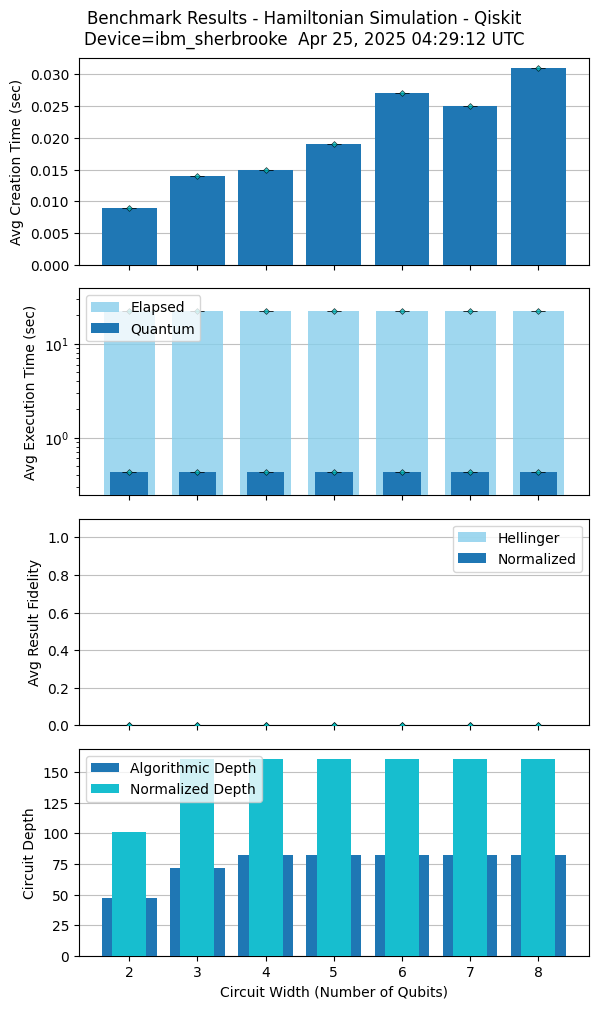

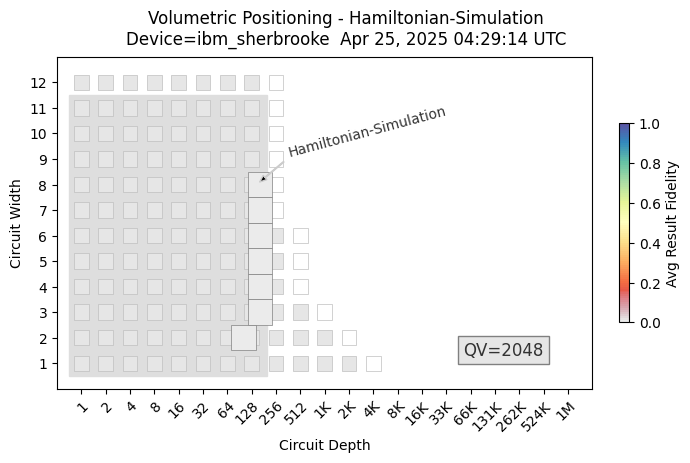


Plots potentially generated!
Check for image files like '_ALL-vplot-2*.png' and 'Benchmark Results - Hamiltonian Simulation - Qiskit*.png'

Execution finished.


In [ ]:
# --- Imports ---
import sys
import time
import math
import numpy as np
import warnings
import os
import traceback
import json

# Matplotlib pour les graphiques
import matplotlib.pyplot as plt

# Qiskit imports
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit_ibm_runtime import QiskitRuntimeService, Sampler
from qiskit.compiler import transpile

# --- 1) Se placer dans le dossier Hamiltonian Simulation ---
print(f"Répertoire courant AVANT changement: {os.getcwd()}")
try:
    base_path = "/content/QC-App-Oriented-Benchmarks"
    target_dir = os.path.join(base_path, "hamiltonian-simulation/qiskit")
    if os.path.exists(target_dir):
        if os.getcwd() != os.path.abspath(target_dir):
             os.chdir(target_dir); print(f"Nouveau répertoire courant: {os.getcwd()}")
        else: print(f"Déjà dans le bon répertoire: {os.getcwd()}")
    else: print(f"ERREUR: Répertoire cible inexistant: {target_dir}"); sys.exit(1)
except Exception as e: print(f"Erreur changement de répertoire: {e}"); sys.exit(1)

# --- Importer les modules et fonctions nécessaires ---
try:
    import metrics as metrics
    # *** CORRECTION: Importer la classe Kernel ***
    from hamiltonian_simulation_kernel import HeisenbergHamiltonianKernel
    # *******************************************
    from metrics import finalize_group
    from metrics import plot_all_app_metrics, store_app_metrics, load_app_metrics
except ImportError as e:
    print(f"Erreur importation modules benchmark: {e}")
    print("Assurez-vous que 'hamiltonian_simulation_kernel.py' et le dossier _common sont accessibles.")
    sys.exit(1)

# --- Configuration Qiskit Runtime ---
warnings.filterwarnings('ignore', category=DeprecationWarning)
try:
    # REMPLACEZ "VOTRE_TOKEN_API_ICI" SI NÉCESSAIRE
    service = QiskitRuntimeService( channel="ibm_quantum", instance="ibm-q/open/main", token="5fbbdfd71d575ba3bcc1a1fc39c96ec43556b3c5c4030bae8adb36345780c9f5bc622a0f07f6a48c7603db47d5dc61e01e4557bb49c07708811babe912d70147")
    backend = service.backend("ibm_sherbrooke")
    print(f"Using backend: {backend.name}"); print(f"Backend basis gates: {backend.basis_gates}")
except Exception as e: print(f"Erreur connexion IBM Quantum: {e}"); sys.exit(1)

# --- Initialisation des Métriques ---
metrics.init_metrics()
metrics.circuit_metrics['subtitle'] = f"Device={backend.name}"
metrics.circuit_metrics['backend_id'] = backend.name
benchmark_name = "Hamiltonian Simulation"; method = None; api_name = "Qiskit"
app_title = f"Benchmark Results - {benchmark_name} - {api_name}"

# --- Paramètres du Benchmark ---
min_qubits=2; max_qubits=8; skip_qubits=1; max_circuits=1; num_shots=1024
# Paramètres spécifiques à Hamiltonian Sim (basés sur precalculated_data.json ou valeurs par défaut)
# Ces valeurs DOIVENT correspondre à celles utilisées pour générer les données de référence si vous vouliez calculer la fidélité.
# Pour juste exécuter et mesurer la profondeur, des valeurs fixes raisonnables suffisent.
hamiltonian_type = 'heisenberg' # Comme dans votre exemple
sim_time_t = 1.0 # Valeur typique, à vérifier dans precalculated_data.json
trotter_steps_k = 5 # Valeur typique, à vérifier dans precalculated_data.json
disorder_w = 1.0 # Valeur typique, à vérifier dans precalculated_data.json
use_XYZ_gates = False # Comme dans votre exemple

# --- Boucle de Génération ---
circuits_info = []
print(f"\nGenerating circuits for {min_qubits} to {max_qubits} qubits ({benchmark_name} - {hamiltonian_type})...")
generation_start_time = time.time(); metrics.start_time = generation_start_time
for num_qubits in range(min_qubits, max_qubits + 1, skip_qubits):
    input_size = num_qubits; print(f"... {num_qubits} qubits")
    s_int = 0 # Index factice
    ts = time.time()
    try:
        # *** Appel de la classe Kernel pour créer le circuit ***
        # Générer des champs aléatoires hx, hz (comme dans le benchmark)
        np.random.seed(0) # Pour la reproductibilité
        hx_random = np.random.uniform(-disorder_w, disorder_w, num_qubits)
        hz_random = np.random.uniform(-disorder_w, disorder_w, num_qubits)

        # Créer l'objet Kernel et obtenir le circuit
        qc_object = HeisenbergHamiltonianKernel(num_qubits, K=trotter_steps_k, t=sim_time_t,
                        hamiltonian=hamiltonian_type, # 'heisenberg'
                        w=disorder_w, hx = hx_random, hz = hz_random,
                        use_XX_YY_ZZ_gates = use_XYZ_gates,
                        method = 1, # Utiliser method=1 (Trotter) comme dans votre exemple
                        random_pauli_flag = False, # Defaults du benchmark
                        init_state = "checkerboard") # Default pour Heisenberg

        qc = qc_object.overall_circuit()
        # *********************************************************
        if not isinstance(qc, QuantumCircuit): continue
        creation_time = time.time() - ts
    except Exception as e_gen:
         print(f"Erreur génération circuit Hamiltonian Sim (nq={num_qubits}): {e_gen}")
         continue

    metrics.store_metric(input_size, s_int, 'create_time', creation_time)
    # Décomposer les portes complexes (comme l'évolution Trotter)
    qc_decomposed = qc.decompose()
    circuits_info.append({"circuit_decomposed": qc_decomposed, "num_qubits": num_qubits, "s_int": s_int})
print(f"\nGenerated {len(circuits_info)} circuits in {time.time() - generation_start_time:.2f}s.")

if not circuits_info: print("\nAucun circuit généré. Arrêt."); sys.exit(1)
all_circuits_decomposed = [info["circuit_decomposed"] for info in circuits_info]

# --- TRANSPILATION EXPLICITE ---
print(f"\nTranspiling {len(all_circuits_decomposed)} circuits for {backend.name}...")
transpilation_start_time = time.time(); transpiled_circuits = None
try:
    opt_level = 1; print(f"Attempting transpilation with optimization_level={opt_level}...")
    transpiled_circuits = transpile(all_circuits_decomposed, backend=backend, optimization_level=opt_level)
    print(f"Transpilation finished in {time.time() - transpilation_start_time:.2f}s.")
except Exception as e: print(f"Erreur transpilation: {e}")

# --- Exécution avec Sampler ---
job = None; result = None; execution_finish_time = time.time()
if transpiled_circuits:
    print(f"\nSubmitting {len(transpiled_circuits)} transpiled circuits...")
    try:
        sampler = Sampler(mode=backend); submit_time = time.time()
        job = sampler.run(pubs=transpiled_circuits, shots=num_shots)
        print(f"Job submitted: {job.job_id()}"); print("Waiting for results...")
        result = job.result(); execution_finish_time = time.time()
        print(f"Job finished in {execution_finish_time - submit_time:.2f}s.")
    except Exception as e: print(f"Erreur exécution: {e}")

# --- Analyse des Résultats et Stockage ---
if result:
    print(f"\nAnalyzing {len(result)} results...")
    # Calcul temps quantique moyen
    total_quantum_time = None; avg_quantum_time = 0.0
    try:
        job_metrics = job.metrics(); total_quantum_time = job_metrics.get('usage', {}).get('quantum_seconds', None)
        if total_quantum_time:
             if len(result) > 0: avg_quantum_time = total_quantum_time / len(result)
             print(f"Total quantum execution time (reported by IBM): {total_quantum_time:.4f}s")
        else: print("Quantum execution time not available.")
    except Exception as e: print(f"Could not retrieve job metrics: {e}")

    for i, pub_result in enumerate(result):
        if i >= len(circuits_info) or i >= len(transpiled_circuits): continue
        info = circuits_info[i]; num_qubits = info["num_qubits"]; s_int = info["s_int"]
        circuit_decomposed = info["circuit_decomposed"]; transpiled_circuit = transpiled_circuits[i]
        try:
            # Extraire comptes
            if not pub_result.data: continue
            creg_keys = list(pub_result.data.keys());
            if not creg_keys: continue
            creg_name = creg_keys[0]; counts_data_bin = getattr(pub_result.data, creg_name)
            counts = counts_data_bin.get_counts()

            # --- Calcul de la Fidélité (OMIS) ---
            fidelity_value = 0.0
            # ------------------------------------

            # Profondeurs et Temps
            depth_value = circuit_decomposed.depth(); transpiled_depth_value = transpiled_circuit.depth()
            quantum_time_value = avg_quantum_time

            # Stockage Métriques (sans fidélité)
            # metrics.store_metric(num_qubits, s_int, 'fidelity', fidelity_value) # OMIS
            metrics.store_metric(num_qubits, s_int, 'depth', depth_value)
            metrics.store_metric(num_qubits, s_int, 'tr_depth', transpiled_depth_value)
            if quantum_time_value > 0.0: metrics.store_metric(num_qubits, s_int, 'quantum_time', quantum_time_value)
            metrics.store_metric(num_qubits, s_int, 'elapsed_time', execution_finish_time - submit_time)
            if avg_quantum_time > 0.0: metrics.store_metric(num_qubits, s_int, 'exec_time', avg_quantum_time)
        except Exception as e: print(f"  Error analyzing result {i}: {e}")

    # --- Finaliser les groupes de métriques ---
    print("\nFinalizing metric groups (for internal state)...")
    processed_qubit_sizes = sorted(list(set(info["num_qubits"] for info in circuits_info)))
    for nq in processed_qubit_sizes:
        try: finalize_group(nq); metrics.report_metrics_for_group(str(nq))
        except Exception as e: print(f"  Error finalizing/reporting group for {nq} qubits: {e}")

    # --- Sauvegarder l'état interne du module metrics dans un fichier ---
    print("\nStoring metrics state to file...")
    # Nom de fichier standard (écrasera les données précédentes)
    data_filename = f"__data/DATA-{backend.name}.json"
    try:
        circuit_metrics_to_save = metrics.circuit_metrics if hasattr(metrics, 'circuit_metrics') else {}
        group_metrics_to_save = metrics.group_metrics if hasattr(metrics, 'group_metrics') else {}
        start_time_to_save = metrics.start_time if hasattr(metrics, 'start_time') else generation_start_time
        end_time_to_save = time.time()
        if not os.path.exists('__data'): os.makedirs('__data')
        with open(data_filename, 'w+') as f:
            data_to_save = { app_title: { "backend_id": backend.name, "start_time": start_time_to_save, "end_time": end_time_to_save, "circuit_metrics": circuit_metrics_to_save, "group_metrics": group_metrics_to_save } }
            json.dump(data_to_save, f, indent=2, sort_keys=True)
        print(f"Metrics stored in {data_filename}")
    except Exception as e: print(f"Error storing metrics to file {data_filename}: {e}"); traceback.print_exc()

# --- Génération des Graphiques (en utilisant le fichier sauvegardé) ---
print("\nGenerating plots from stored file data...")
try:
    if os.path.exists(data_filename):
        plot_all_app_metrics(backend.name, do_all_plots=True, is_individual=True)
        print(f"\nPlots potentially generated!")
        print(f"Check for image files like '_ALL-vplot-2*.png' and '{app_title}*.png'")
    else: print(f"\nErreur: Fichier de données '{data_filename}' non trouvé.")
except Exception as e: print(f"\nError generating plots from file: {e}"); traceback.print_exc()

# --- Fin ---
warnings.filterwarnings('default', category=DeprecationWarning)
print("\nExecution finished.")

Répertoire courant AVANT changement: /content/QC-App-Oriented-Benchmarks/hamiltonian-simulation/qiskit
Déjà dans le bon répertoire: /content/QC-App-Oriented-Benchmarks/hamiltonian-simulation/qiskit
Using backend: ibm_sherbrooke
Backend basis gates: ['ecr', 'id', 'rz', 'sx', 'x']
... execution starting at Apr 25, 2025 04:35:55 UTC

Generating circuits for 2 to 8 qubits (Hamiltonian Simulation - heisenberg)...
... 2 qubits
... 3 qubits
... 4 qubits
... 5 qubits
... 6 qubits
... 7 qubits
... 8 qubits

Generated 7 circuits in 0.21s.

Transpiling 7 circuits for ibm_sherbrooke...
Attempting transpilation with optimization_level=1...
Transpilation finished in 0.13s.

Submitting 7 transpiled circuits...
Job submitted: d05h2esnhqag008yb15g
Waiting for results...
Job finished in 39.76s.

Analyzing 7 results...
Total quantum execution time (reported by IBM): 3.0000s

Finalizing metric groups (for internal state)...
************
Average Circuit Algorithmic Depth, ξ (xi) for the 2 qubit group = 47,

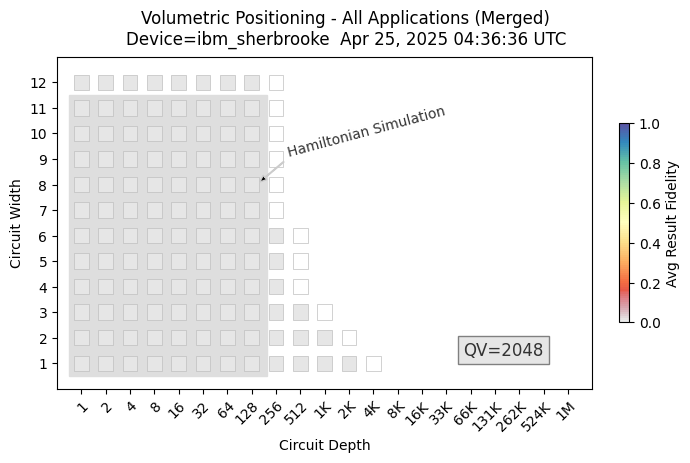

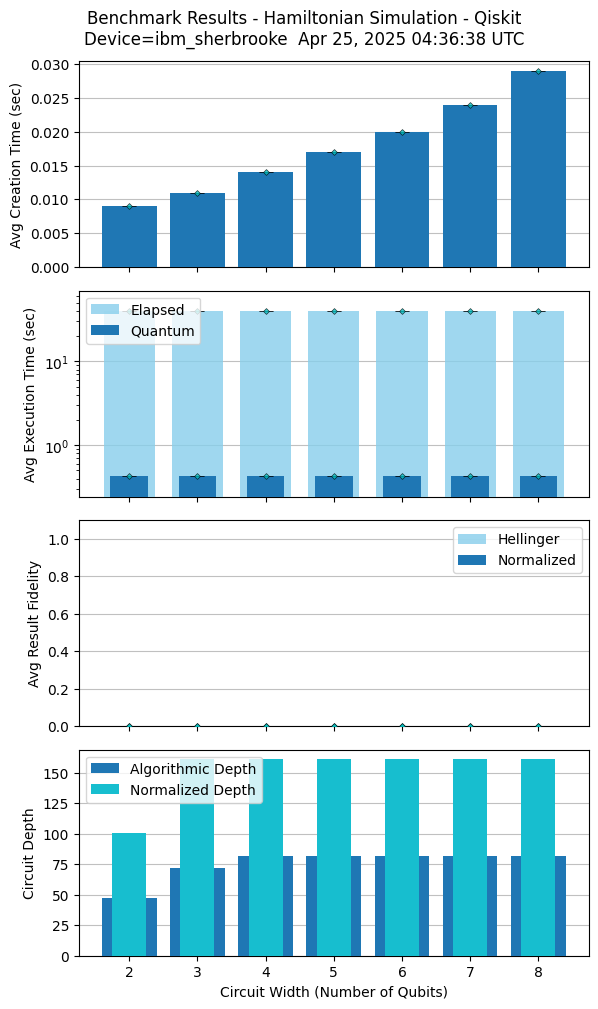

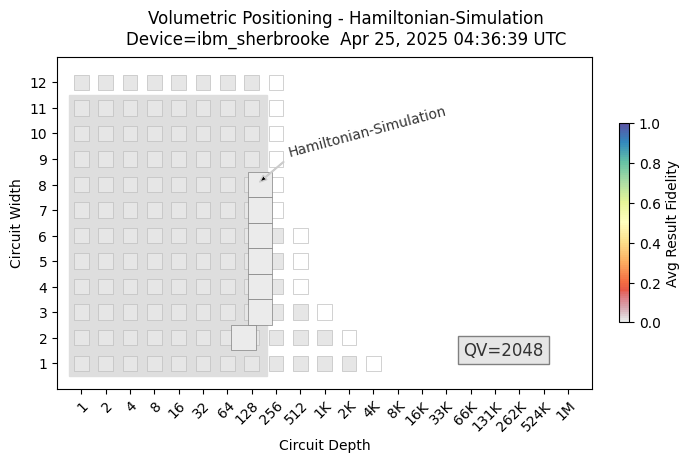


Plots potentially generated!
Check for image files like '_ALL-vplot-2*.png' and 'Benchmark Results - Hamiltonian Simulation - Qiskit*.png'

Execution finished.


In [ ]:
# --- Imports ---
import sys
import time
import math
import numpy as np
import warnings
import os
import traceback
import json

# Matplotlib pour les graphiques
import matplotlib.pyplot as plt

# Qiskit imports
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit_ibm_runtime import QiskitRuntimeService, Sampler
from qiskit.compiler import transpile

# --- 1) Se placer dans le dossier Hamiltonian Simulation ---
print(f"Répertoire courant AVANT changement: {os.getcwd()}")
try:
    base_path = "/content/QC-App-Oriented-Benchmarks"
    target_dir = os.path.join(base_path, "hamiltonian-simulation/qiskit")
    if os.path.exists(target_dir):
        if os.getcwd() != os.path.abspath(target_dir):
             os.chdir(target_dir); print(f"Nouveau répertoire courant: {os.getcwd()}")
        else: print(f"Déjà dans le bon répertoire: {os.getcwd()}")
    else: print(f"ERREUR: Répertoire cible inexistant: {target_dir}"); sys.exit(1)
except Exception as e: print(f"Erreur changement de répertoire: {e}"); sys.exit(1)

# --- Importer les modules et fonctions nécessaires ---
try:
    import metrics as metrics
    # *** CORRECTION: Importer la classe Kernel ***
    from hamiltonian_simulation_kernel import HeisenbergHamiltonianKernel
    # *******************************************
    from metrics import finalize_group
    from metrics import plot_all_app_metrics, store_app_metrics, load_app_metrics
except ImportError as e:
    print(f"Erreur importation modules benchmark: {e}")
    print("Assurez-vous que 'hamiltonian_simulation_kernel.py' et le dossier _common sont accessibles.")
    sys.exit(1)

# --- Configuration Qiskit Runtime ---
warnings.filterwarnings('ignore', category=DeprecationWarning)
try:
    # REMPLACEZ "VOTRE_TOKEN_API_ICI" SI NÉCESSAIRE
    service = QiskitRuntimeService( channel="ibm_quantum", instance="ibm-q/open/main", token="5fbbdfd71d575ba3bcc1a1fc39c96ec43556b3c5c4030bae8adb36345780c9f5bc622a0f07f6a48c7603db47d5dc61e01e4557bb49c07708811babe912d70147")
    backend = service.backend("ibm_sherbrooke")
    print(f"Using backend: {backend.name}"); print(f"Backend basis gates: {backend.basis_gates}")
except Exception as e: print(f"Erreur connexion IBM Quantum: {e}"); sys.exit(1)

# --- Initialisation des Métriques ---
metrics.init_metrics()
metrics.circuit_metrics['subtitle'] = f"Device={backend.name}"
metrics.circuit_metrics['backend_id'] = backend.name
benchmark_name = "Hamiltonian Simulation"; method = None; api_name = "Qiskit"
app_title = f"Benchmark Results - {benchmark_name} - {api_name}"

# --- Paramètres du Benchmark ---
min_qubits=2; max_qubits=8; skip_qubits=1; max_circuits=1; num_shots=1024
# Paramètres spécifiques à Hamiltonian Sim (basés sur precalculated_data.json ou valeurs par défaut)
# Ces valeurs DOIVENT correspondre à celles utilisées pour générer les données de référence si vous vouliez calculer la fidélité.
# Pour juste exécuter et mesurer la profondeur, des valeurs fixes raisonnables suffisent.
hamiltonian_type = 'heisenberg' # Comme dans votre exemple
sim_time_t = 1.0 # Valeur typique, à vérifier dans precalculated_data.json
trotter_steps_k = 5 # Valeur typique, à vérifier dans precalculated_data.json
disorder_w = 1.0 # Valeur typique, à vérifier dans precalculated_data.json
use_XYZ_gates = False # Comme dans votre exemple

# --- Boucle de Génération ---
circuits_info = []
print(f"\nGenerating circuits for {min_qubits} to {max_qubits} qubits ({benchmark_name} - {hamiltonian_type})...")
generation_start_time = time.time(); metrics.start_time = generation_start_time
for num_qubits in range(min_qubits, max_qubits + 1, skip_qubits):
    input_size = num_qubits; print(f"... {num_qubits} qubits")
    s_int = 0 # Index factice
    ts = time.time()
    try:
        # *** Appel de la classe Kernel pour créer le circuit ***
        # Générer des champs aléatoires hx, hz (comme dans le benchmark)
        np.random.seed(0) # Pour la reproductibilité
        hx_random = np.random.uniform(-disorder_w, disorder_w, num_qubits)
        hz_random = np.random.uniform(-disorder_w, disorder_w, num_qubits)

        # Créer l'objet Kernel et obtenir le circuit
        qc_object = HeisenbergHamiltonianKernel(num_qubits, K=trotter_steps_k, t=sim_time_t,
                        hamiltonian=hamiltonian_type, # 'heisenberg'
                        w=disorder_w, hx = hx_random, hz = hz_random,
                        use_XX_YY_ZZ_gates = use_XYZ_gates,
                        method = 2, # Utiliser method=1 (Trotter) comme dans votre exemple
                        random_pauli_flag = False, # Defaults du benchmark
                        init_state = "checkerboard") # Default pour Heisenberg

        qc = qc_object.overall_circuit()
        # *********************************************************
        if not isinstance(qc, QuantumCircuit): continue
        creation_time = time.time() - ts
    except Exception as e_gen:
         print(f"Erreur génération circuit Hamiltonian Sim (nq={num_qubits}): {e_gen}")
         continue

    metrics.store_metric(input_size, s_int, 'create_time', creation_time)
    # Décomposer les portes complexes (comme l'évolution Trotter)
    qc_decomposed = qc.decompose()
    circuits_info.append({"circuit_decomposed": qc_decomposed, "num_qubits": num_qubits, "s_int": s_int})
print(f"\nGenerated {len(circuits_info)} circuits in {time.time() - generation_start_time:.2f}s.")

if not circuits_info: print("\nAucun circuit généré. Arrêt."); sys.exit(1)
all_circuits_decomposed = [info["circuit_decomposed"] for info in circuits_info]

# --- TRANSPILATION EXPLICITE ---
print(f"\nTranspiling {len(all_circuits_decomposed)} circuits for {backend.name}...")
transpilation_start_time = time.time(); transpiled_circuits = None
try:
    opt_level = 1; print(f"Attempting transpilation with optimization_level={opt_level}...")
    transpiled_circuits = transpile(all_circuits_decomposed, backend=backend, optimization_level=opt_level)
    print(f"Transpilation finished in {time.time() - transpilation_start_time:.2f}s.")
except Exception as e: print(f"Erreur transpilation: {e}")

# --- Exécution avec Sampler ---
job = None; result = None; execution_finish_time = time.time()
if transpiled_circuits:
    print(f"\nSubmitting {len(transpiled_circuits)} transpiled circuits...")
    try:
        sampler = Sampler(mode=backend); submit_time = time.time()
        job = sampler.run(pubs=transpiled_circuits, shots=num_shots)
        print(f"Job submitted: {job.job_id()}"); print("Waiting for results...")
        result = job.result(); execution_finish_time = time.time()
        print(f"Job finished in {execution_finish_time - submit_time:.2f}s.")
    except Exception as e: print(f"Erreur exécution: {e}")

# --- Analyse des Résultats et Stockage ---
if result:
    print(f"\nAnalyzing {len(result)} results...")
    # Calcul temps quantique moyen
    total_quantum_time = None; avg_quantum_time = 0.0
    try:
        job_metrics = job.metrics(); total_quantum_time = job_metrics.get('usage', {}).get('quantum_seconds', None)
        if total_quantum_time:
             if len(result) > 0: avg_quantum_time = total_quantum_time / len(result)
             print(f"Total quantum execution time (reported by IBM): {total_quantum_time:.4f}s")
        else: print("Quantum execution time not available.")
    except Exception as e: print(f"Could not retrieve job metrics: {e}")

    for i, pub_result in enumerate(result):
        if i >= len(circuits_info) or i >= len(transpiled_circuits): continue
        info = circuits_info[i]; num_qubits = info["num_qubits"]; s_int = info["s_int"]
        circuit_decomposed = info["circuit_decomposed"]; transpiled_circuit = transpiled_circuits[i]
        try:
            # Extraire comptes
            if not pub_result.data: continue
            creg_keys = list(pub_result.data.keys());
            if not creg_keys: continue
            creg_name = creg_keys[0]; counts_data_bin = getattr(pub_result.data, creg_name)
            counts = counts_data_bin.get_counts()

            # --- Calcul de la Fidélité (OMIS) ---
            fidelity_value = 0.0
            # ------------------------------------

            # Profondeurs et Temps
            depth_value = circuit_decomposed.depth(); transpiled_depth_value = transpiled_circuit.depth()
            quantum_time_value = avg_quantum_time

            # Stockage Métriques (sans fidélité)
            # metrics.store_metric(num_qubits, s_int, 'fidelity', fidelity_value) # OMIS
            metrics.store_metric(num_qubits, s_int, 'depth', depth_value)
            metrics.store_metric(num_qubits, s_int, 'tr_depth', transpiled_depth_value)
            if quantum_time_value > 0.0: metrics.store_metric(num_qubits, s_int, 'quantum_time', quantum_time_value)
            metrics.store_metric(num_qubits, s_int, 'elapsed_time', execution_finish_time - submit_time)
            if avg_quantum_time > 0.0: metrics.store_metric(num_qubits, s_int, 'exec_time', avg_quantum_time)
        except Exception as e: print(f"  Error analyzing result {i}: {e}")

    # --- Finaliser les groupes de métriques ---
    print("\nFinalizing metric groups (for internal state)...")
    processed_qubit_sizes = sorted(list(set(info["num_qubits"] for info in circuits_info)))
    for nq in processed_qubit_sizes:
        try: finalize_group(nq); metrics.report_metrics_for_group(str(nq))
        except Exception as e: print(f"  Error finalizing/reporting group for {nq} qubits: {e}")

    # --- Sauvegarder l'état interne du module metrics dans un fichier ---
    print("\nStoring metrics state to file...")
    # Nom de fichier standard (écrasera les données précédentes)
    data_filename = f"__data/DATA-{backend.name}.json"
    try:
        circuit_metrics_to_save = metrics.circuit_metrics if hasattr(metrics, 'circuit_metrics') else {}
        group_metrics_to_save = metrics.group_metrics if hasattr(metrics, 'group_metrics') else {}
        start_time_to_save = metrics.start_time if hasattr(metrics, 'start_time') else generation_start_time
        end_time_to_save = time.time()
        if not os.path.exists('__data'): os.makedirs('__data')
        with open(data_filename, 'w+') as f:
            data_to_save = { app_title: { "backend_id": backend.name, "start_time": start_time_to_save, "end_time": end_time_to_save, "circuit_metrics": circuit_metrics_to_save, "group_metrics": group_metrics_to_save } }
            json.dump(data_to_save, f, indent=2, sort_keys=True)
        print(f"Metrics stored in {data_filename}")
    except Exception as e: print(f"Error storing metrics to file {data_filename}: {e}"); traceback.print_exc()

# --- Génération des Graphiques (en utilisant le fichier sauvegardé) ---
print("\nGenerating plots from stored file data...")
try:
    if os.path.exists(data_filename):
        plot_all_app_metrics(backend.name, do_all_plots=True, is_individual=True)
        print(f"\nPlots potentially generated!")
        print(f"Check for image files like '_ALL-vplot-2*.png' and '{app_title}*.png'")
    else: print(f"\nErreur: Fichier de données '{data_filename}' non trouvé.")
except Exception as e: print(f"\nError generating plots from file: {e}"); traceback.print_exc()

# --- Fin ---
warnings.filterwarnings('default', category=DeprecationWarning)
print("\nExecution finished.")